In [124]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [125]:
Bunga = cv2.imread('Assets/Bunga.png', cv2.IMREAD_GRAYSCALE)
Langit = cv2.imread('Assets/Langit.png', cv2.IMREAD_GRAYSCALE)
Meledak = cv2.imread('Assets/Meledak.png', cv2.IMREAD_COLOR_RGB)
Windut = cv2.imread('Assets/Windut.png', cv2.IMREAD_GRAYSCALE)

Meledak: (720, 720, 3)


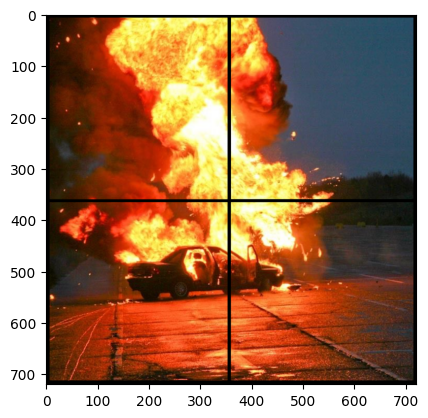

In [126]:
plt.imshow(Meledak)
print("Meledak:", Meledak.shape)

Text(0.5, 1.0, 'Gambar D')

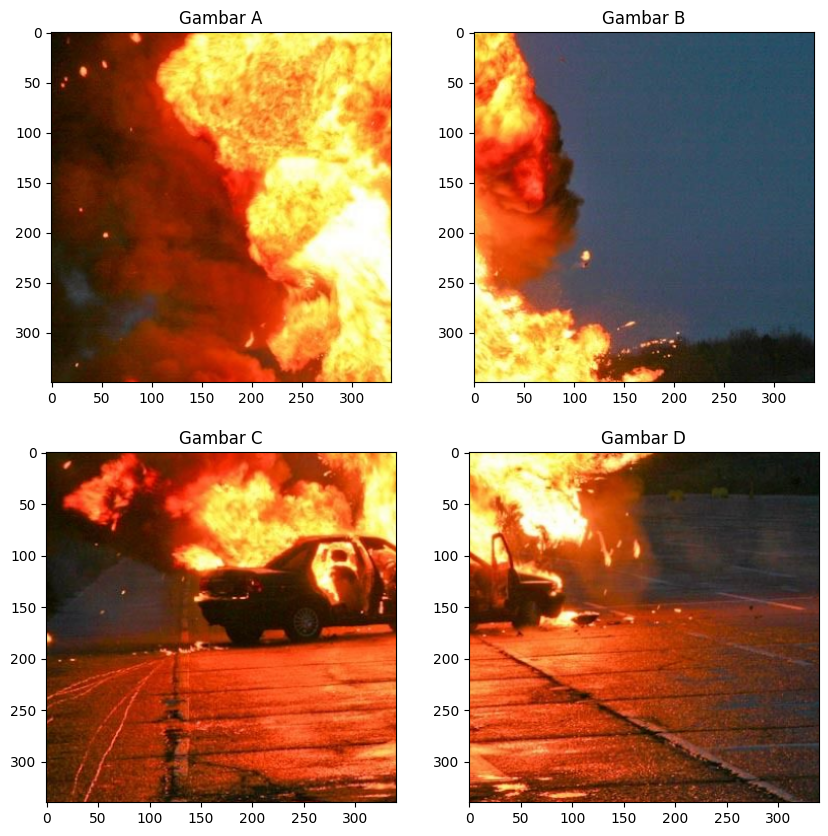

In [127]:
def slicing(gambar, a, b, mode='H'):
 return gambar[a:b, :] if mode == 'H' else gambar[:, a:b]

slicingAtas = slicing(Meledak, 0, 360,  mode='H')
slicingBawah = slicing(Meledak, 360, 720, mode='H')
Bersih1 = slicing(slicingAtas, 10, 360, mode='H')
Bersih2 = slicing(slicingBawah, 10, 350, mode='H')
kiriAtas = slicing(Bersih1, 10, 350, mode='V')
kananAtas = slicing(Bersih1, 370, 710, mode='V')
kiriBawah = slicing(Bersih2, 10, 350, mode='V')
kananBawah = slicing(Bersih2, 370, 710, mode='V')



fig, axs = plt.subplots(2, 2, figsize = (10,10))

axs[0, 0].imshow(kiriAtas, cmap='gray')
axs[0, 0].set_title("Gambar A")

axs[0, 1].imshow(kananAtas, cmap='gray')
axs[0, 1].set_title("Gambar B")

axs[1, 0].imshow(kiriBawah, cmap='gray')
axs[1, 0].set_title("Gambar C")

axs[1, 1].imshow(kananBawah, cmap='gray')
axs[1, 1].set_title("Gambar D")

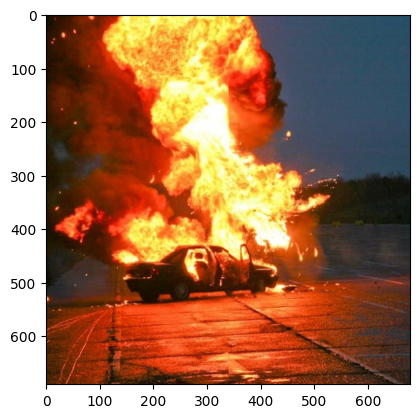

In [145]:
def horizontal(citra_1, citra_2):
    c1, c2 = np.array(citra_1), np.array(citra_2)
    tinggi = max(c1.shape[0], c2.shape[0])
    lebar = c1.shape[1] + c2.shape[1]
    hasil = np.zeros((tinggi, lebar, 3), dtype=np.uint8)
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1
    hasil[0:c2.shape[0], c1.shape[1]:] = c2
    return hasil

def vertikal(citra_1, citra_2):
    c1, c2 = np.array(citra_1), np.array(citra_2)
    tinggi = c1.shape[0] + c2.shape[0]
    lebar = max(c1.shape[1], c2.shape[1])
    hasil = np.zeros((tinggi, lebar, 3), dtype=np.uint8)
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1
    hasil[c1.shape[0]:, 0:c2.shape[1]] = c2
    return hasil


horizontalAB = horizontal(kiriAtas, kananAtas)
horizontalCD = horizontal(kiriBawah, kananBawah)

meledakFull = vertikal(horizontalAB, horizontalCD)

plt.imshow(meledakFull)
plt.show()

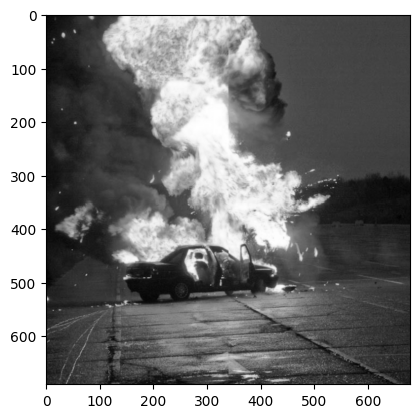

In [129]:
meledakFullGray = cv2.cvtColor(meledakFull, cv2.COLOR_RGB2GRAY)
plt.imshow(meledakFullGray, cmap='gray')

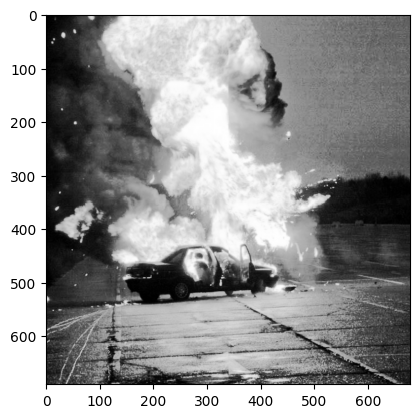

In [130]:
def ekualisasi(citra):
    height, width = citra.shape
    hist = np.zeros(256, dtype=int)
    for i in range(height):
        for j in range(width):
            pixel = citra[i, j]
            hist[pixel] += 1
    cdf = np.zeros(256, dtype=int)
    cdf[0] = hist[0]

    for i in range(1, 256):
        cdf[i] = cdf[i - 1] + hist[i]

    cdf_normal = np.round(cdf * 255 / (height * width)).astype(np.uint8)

    hasil = np.zeros_like(citra, dtype=np.uint8)

    for i in range(height):
        for j in range(width):
            hasil[i, j] = cdf_normal[citra[i, j]]

    return hasil

meledakEkualisasi = ekualisasi(meledakFullGray)
plt.imshow(meledakEkualisasi, cmap='gray')
plt.show()

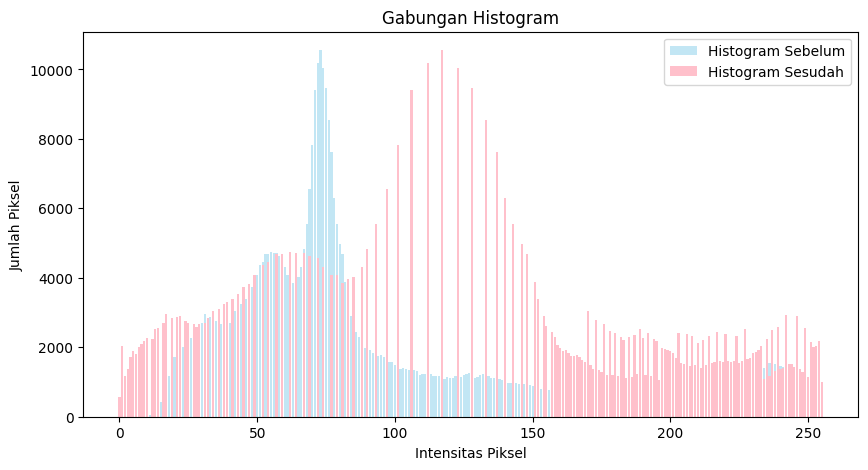

In [ ]:
def buat_hist(citra):
    histogram = [0] * 256
    height = len(citra)
    width = len(citra[0]) if height > 0 else 0
    for i in range(height):
        for j in range(width):
            val = int(citra[i][j])
            histogram[val] += 1
    return histogram

def plot_dua_histogram(hist1, hist2, title):
    plt.figure(figsize=(10,5))

    plt.bar(range(256), hist1, color='skyblue', alpha=0.5, label='Histogram Sebelum')
    plt.bar(range(256), hist2, color='pink', alpha=1, label='Histogram Sesudah')

    plt.title("Gabungan Histogram")
    plt.xlabel("Intensitas Piksel")
    plt.ylabel("Jumlah Piksel")

    plt.legend()
    plt.show()

hist_awal = buat_hist(meledakFullGray)
hist_hasil = buat_hist(meledakEkualisasi)

plot_dua_histogram(hist_awal, hist_hasil, "Perbandingan Histogram")


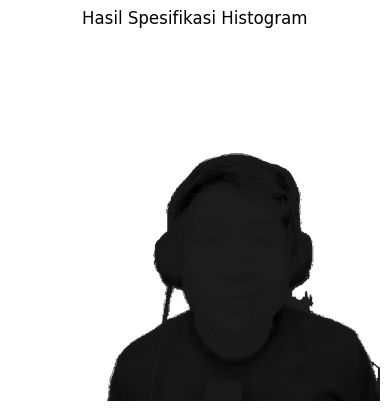

In [144]:
def spesifikasi_histogram(citra_asal, citra_target):

    hist_asal = np.zeros(256, dtype=int)
    hist_target = np.zeros(256, dtype=int)
    height_asal, width_asal = citra_asal.shape

    for i in range(height_asal):
        for j in range(width_asal):
            pixel = citra_asal[i, j]
            hist_asal[pixel] += 1

    height_target, width_target = citra_target.shape

    for i in range(height_target):
        for j in range(width_target):
            pixel = citra_target[i, j]
            hist_target[pixel] += 1

    cdf_asal = np.zeros(256, dtype=float)
    cdf_target = np.zeros(256, dtype=float)
    cdf_asal[0] = hist_asal[0]
    cdf_target[0] = hist_target[0]

    for i in range(1, 256):
        cdf_asal[i] = cdf_asal[i - 1] + hist_asal[i]
        cdf_target[i] = cdf_target[i - 1] + hist_target[i]

    cdf_asal = cdf_asal / cdf_asal[-1]
    cdf_target = cdf_target / cdf_target[-1]

    map_hist = np.zeros(256, dtype=np.uint8)

    for i in range(256):

        selisih_min = abs(cdf_asal[i] - cdf_target[0])
        indeks = 0

        for j in range(256):

            selisih = abs(cdf_asal[i] - cdf_target[j])

            if selisih < selisih_min:
                selisih_min = selisih
                indeks = j

        map_hist[i] = indeks

    hasil = np.zeros((height_asal, width_asal), dtype=np.uint8)

    for i in range(height_asal):
        for j in range(width_asal):
            hasil[i, j] = map_hist[citra_asal[i, j]]

    return hasil

spesifikasi = spesifikasi_histogram(Windut, Bunga)

plt.imshow(spesifikasi, cmap='gray')
plt.title("Hasil Spesifikasi Histogram")
plt.axis('off')

plt.show()

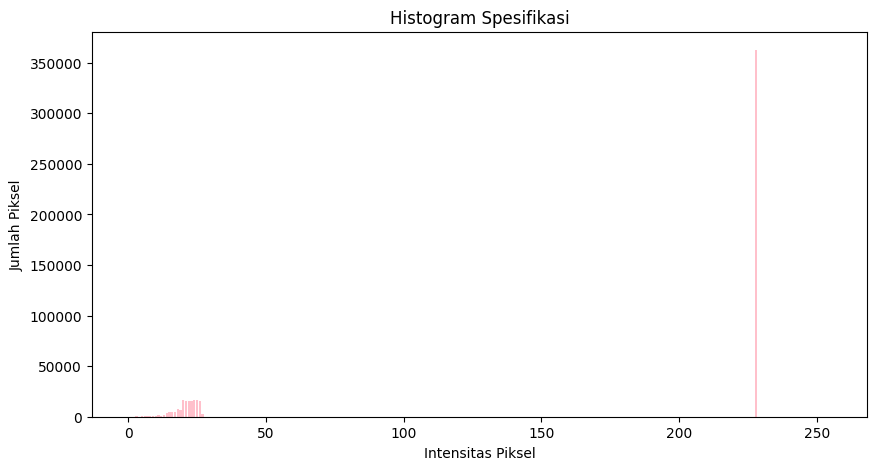

In [142]:
def plot_histogram(histogram, title, ImgColor):
    plt.figure(figsize=(10, 5))
    plt.xlabel("Intensitas Piksel")
    plt.title(title)
    plt.ylabel("Jumlah Piksel")
    plt.bar(range(256), histogram, color=ImgColor, width=0.8)
    plt.show()

hist_spesifikasi = buat_hist(spesifikasi)
plot_histogram(hist_spesifikasi, "Histogram Spesifikasi", "pink")

[[228 228 228 ... 228 228 228]
 [228 228 228 ... 228 228 228]
 [228 228 228 ... 228 228 228]
 ...
 [228 228 228 ...  10  11  11]
 [228 228 228 ...  10  11  11]
 [228 228 228 ...  10  11  11]] (1400, 1400)


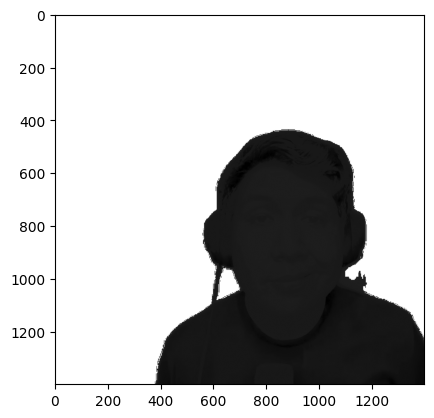

In [ ]:
def dilatasi(image, p1=0, p2=0, p3=0, p4=0):
    h, w = image.shape
    dilated = np.zeros((h * 2, w * 2)).astype(int)
    for y in range(h * 2):
        for x in range(w * 2):
            dilated[y][x] = image[int(y / 2)][int(x / 2)]
    sy, ey = max(0, p1), min(h * 2, h * 2 - p2)
    sx, ex = max(0, p3), min(w * 2, w * 2 - p4)
    return dilated[sy:ey, sx:ex]

cropGambarA = dilatasi(spesifikasi, 40, 0, 0, 40)

plt.imshow(cropGambarA, cmap="gray")
print(cropGambarA, cropGambarA.shape)
